In [1]:
SEED = 24520789

In [2]:
# Reproducibility enforcement and quick seed check
import os, random, numpy as np, torch

# Ensure Python hash seed is stable for reproducible hashing behavior
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# Prefer deterministic algorithms where possible (can reduce throughput)
try:
    torch.use_deterministic_algorithms(True)
    print('torch.use_deterministic_algorithms(True) enabled')
except Exception as e:
    print('Could not enable torch.use_deterministic_algorithms:', e)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print('Falling back to cudnn deterministic mode')

# Quick seed check: sample twice after reseeding and compare

def _sample_once():
    return {
        'py_random': [random.random() for _ in range(3)],
        'np_rand': np.random.rand(3).tolist(),
        'torch_cpu': torch.rand(3).tolist(),
    }

a = _sample_once()
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
b = _sample_once()
print('Seed check match:', a == b)
print('Sample (1):', a)
print('Sample (2):', b)

torch.use_deterministic_algorithms(True) enabled
Seed check match: True
Sample (1): {'py_random': [0.9459758336886895, 0.22906676069050858, 0.027838354396150677], 'np_rand': [0.9834658404741958, 0.8101150811275819, 0.7300948332552615], 'torch_cpu': [0.7672545909881592, 0.558594822883606, 0.38946056365966797]}
Sample (2): {'py_random': [0.9459758336886895, 0.22906676069050858, 0.027838354396150677], 'np_rand': [0.9834658404741958, 0.8101150811275819, 0.7300948332552615], 'torch_cpu': [0.7672545909881592, 0.558594822883606, 0.38946056365966797]}


# HaGRID 5-Class Object Detection (PyTorch From Scratch)

This notebook does the following:
1. Downloads HaGRID from Kaggle.
2. Builds and trains custom object detection models from scratch in PyTorch.
3. Compares model quality and speed (accuracy, precision, recall, IoU, and latency in ms).

Target classes in this notebook:
- `one` (gesture 1)
- `peace` (gesture 2)
- `three` (gesture 3)
- `four` (gesture 4)
- `fist`

In [3]:
import os
import json
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from tqdm.auto import tqdm
from pathlib import Path
from collections import Counter
import importlib.util

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# --- ENVIRONMENT-AWARE PATHS ---
def get_environment() -> str:
    if os.getenv('KAGGLE_DATA_FOLDER') or Path('/kaggle/input').exists():
        return 'kaggle'
    if importlib.util.find_spec('google.colab') is not None:
        return 'colab'
    return 'local'

ENVIRONMENT = get_environment()

if ENVIRONMENT == 'kaggle':
    DATASET_ROOT = Path('/kaggle/input/datasets/innominate817/hagrid-sample-30k-384p/hagrid-sample-30k-384p')
    MODEL_DIR = Path('/kaggle/working/models')
elif ENVIRONMENT == 'colab':
    DATASET_ROOT = Path('/content/hagrid_dataset/hagrid-sample-30k-384p')
    MODEL_DIR = Path('/content/models')
else:
    REPO_ROOT = Path('.').resolve()
    DATASET_ROOT = REPO_ROOT / 'data' / 'hagrid-sample-30k-384p-5class'
    MODEL_DIR = REPO_ROOT / 'models'

EXTRACT_DIR = DATASET_ROOT
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(f'Environment: {ENVIRONMENT}')
print(f'Dataset root: {DATASET_ROOT}')
print(f'Model dir: {MODEL_DIR}')

KEEP_CLASSES = ['one', 'peace', 'three', 'four', 'fist']
TARGET_CLASSES = KEEP_CLASSES
CLASS_TO_ID = {c: i for i, c in enumerate(TARGET_CLASSES)}
ID_TO_CLASS = {i: c for c, i in CLASS_TO_ID.items()}
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}


Environment: kaggle
Dataset root: /kaggle/input/datasets/innominate817/hagrid-sample-30k-384p/hagrid-sample-30k-384p
Model dir: /kaggle/working/models


In [4]:
def build_filename_index(img_root: Path, class_names=None):
    img_root = Path(img_root)
    index = {}
    if not img_root.exists():
        return index

    if class_names:
        candidate_dirs = [img_root / f"train_val_{class_name}" for class_name in class_names]
        candidate_dirs = [d for d in candidate_dirs if d.exists()]
    else:
        candidate_dirs = [img_root]

    for root_dir in candidate_dirs:
        for p in root_dir.rglob("*"):
            if p.suffix.lower() in IMG_EXTS and p.is_file():
                stem = p.stem
                name = p.name
                index.setdefault(stem, p)
                index.setdefault(name, p)
                try:
                    rel = str(p.relative_to(img_root))
                    index.setdefault(rel, p)
                except Exception:
                    pass
    return index


def resolve_image_path(filename_index: dict, image_key: str):
    if image_key is None:
        return None
    key = str(image_key)
    if key in filename_index:
        return filename_index[key]
    for ext in IMG_EXTS:
        if (key + ext) in filename_index:
            return filename_index[key + ext]
    stem = Path(key).stem
    if stem in filename_index:
        return filename_index[stem]
    return None


def xywh_to_xyxy(box, w: int, h: int, normalized: bool = True, xywh_mode: str = "topleft"):
    x, y, bw, bh = box[:4]
    if normalized:
        x = float(x) * w
        y = float(y) * h
        bw = float(bw) * w
        bh = float(bh) * h

    if xywh_mode == "center":
        x1 = float(x - bw / 2.0)
        y1 = float(y - bh / 2.0)
        x2 = float(x + bw / 2.0)
        y2 = float(y + bh / 2.0)
    else:
        # HaGRID bboxes are top-left xywh in this project dataset.
        x1 = float(x)
        y1 = float(y)
        x2 = float(x + bw)
        y2 = float(y + bh)

    x1 = max(0.0, min(x1, w))
    y1 = max(0.0, min(y1, h))
    x2 = max(0.0, min(x2, w))
    y2 = max(0.0, min(y2, h))
    return x1, y1, x2, y2

In [5]:
import os
import json
import time
import random
import shutil
import subprocess
import hashlib
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# SEED = 42 # Removed original seed definition
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Also set CUDA seeds for reproducibility on GPU
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

REPO_ROOT = Path(".").resolve()
DATA_ROOT = REPO_ROOT / "data"
DATA_ROOT.mkdir(parents=True, exist_ok=True)
REGISTRY_PATH = REPO_ROOT / "dataset_registry.json"


def load_registry(path: Path):
    if path.exists():
        try:
            return json.loads(path.read_text(encoding="utf-8"))
        except Exception:
            pass
    return {"datasets": {}}


def save_registry(path: Path, registry: dict):
    path.write_text(json.dumps(registry, indent=2), encoding="utf-8")


def sha1_of_file(path: Path):
    if not path.exists():
        return None
    h = hashlib.sha1()
    with path.open("rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()


def ensure_kaggle_installed():
    try:
        import kaggle  # noqa: F401
        print("kaggle package already available in notebook kernel")
    except Exception:
        print("Installing kaggle package in notebook kernel...")
        subprocess.check_call(["python", "-m", "pip", "install", "-q", "kaggle"])
        import kaggle  # noqa: F401
        print("kaggle package installed")

Device: cuda


## 1) One-Time Kaggle Setup + Filtered 5-Class Dataset

This section does all of this:
- Uses the Kaggle token file from `C:/Users/<you>/.kaggle/access_token.txt`.
- Detects if the filtered HaGRID Sample 30k 384p 5-class dataset is already present in this repo.
- Builds a repo-local filtered copy that keeps only the five train classes: `one`, `peace`, `three`, `four`, `fist`.
- Stores dataset metadata in `dataset_registry.json` at repo root.
- Verifies the reduced dataset afterward by counting only the kept image folders and annotation JSONs.

Dataset reference: `innominate817/hagrid-sample-30k-384p`.

Important:
- The notebook now uses the filtered 5-class copy stored at `data/hagrid-sample-30k-384p-5class`.
- The later parsing/training cells work with that filtered dataset root.

In [6]:
# Align downstream cells with the dataset prepared in cell 2.
EXTRACT_DIR = DATASET_ROOT
print("Using dataset root:", EXTRACT_DIR)
print("JSON files:", len(list(EXTRACT_DIR.rglob("*.json"))))
print("Image files:", len(list(EXTRACT_DIR.rglob("*.jpg"))))

Using dataset root: /kaggle/input/datasets/innominate817/hagrid-sample-30k-384p/hagrid-sample-30k-384p
JSON files: 18
Image files: 31833


In [7]:
def parse_hagrid_like_annotations(dataset_root: Path, target_classes):
    """Parse the exact HaGRID 5-class repo layout into flat training records.

    The dataset layout is:
    - ann_train_val/{class}.json
    - hagrid_30k/train_val_{class}/<image_id>.jpg

    Each JSON is a dict keyed by image id, and each value contains:
    - bboxes: list[[x, y, w, h]] (top-left xywh)
    - labels: list[str]
    - user_id: str (for better data splitting)
    """
    ann_dir = dataset_root / "ann_train_val"
    img_root = dataset_root / "hagrid_30k"
    json_files = [ann_dir / f"{class_name}.json" for class_name in target_classes]

    print(f"Found {len(json_files)} annotation files")
    print("Building filename index for target classes only...")
    filename_index = build_filename_index(img_root, target_classes)
    print(f"Indexed {len(filename_index)} image-name entries")

    records = []
    image_size_cache = {}
    t_start = time.perf_counter()
    t_last_report = t_start
    skipped_missing_image = 0
    skipped_bad_json = 0
    total_images_seen = 0

    for jf in tqdm(json_files, desc="Parsing annotations"):
        if not jf.exists():
            continue
        try:
            data = json.loads(jf.read_text(encoding="utf-8"))
        except Exception:
            skipped_bad_json += 1
            continue

        if not isinstance(data, dict):
            skipped_bad_json += 1
            continue

        for image_key, item in data.items():
            if not isinstance(item, dict):
                continue

            labels = item.get("labels") or []
            bboxes = item.get("bboxes") or []
            if not labels or not bboxes:
                continue

            total_images_seen += 1
            img_path = resolve_image_path(filename_index, image_key)
            if img_path is None:
                skipped_missing_image += 1
                continue

            try:
                if img_path in image_size_cache:
                    w, h = image_size_cache[img_path]
                else:
                    # Read only image headers for size; avoid full decode during parsing.
                    with Image.open(img_path) as img_pil:
                        w, h = img_pil.size
                    image_size_cache[img_path] = (w, h)
            except Exception:
                continue

            # ADDED: Capture user_id for better data splitting
            user_id = item.get("user_id", "unknown")

            for label, box in zip(labels, bboxes):
                if label not in target_classes:
                    continue
                if not isinstance(box, (list, tuple)) or len(box) < 4:
                    continue
                normalized = max(box[:4]) <= 1.5
                x1, y1, x2, y2 = xywh_to_xyxy(box[:4], w, h, normalized=normalized, xywh_mode="topleft")
                records.append({
                    "image_path": str(img_path),
                    "bbox_xyxy": [x1, y1, x2, y2],
                    "class_id": CLASS_TO_ID[label],
                    "user_id": user_id,  # ADDED: user_id for splitting
                })

            if len(records) % 5000 == 0 and len(records) > 0:
                now = time.perf_counter()
                elapsed = now - t_start
                since_last = now - t_last_report
                t_last_report = now
                print(f"  Parsed {len(records):,} records from {total_images_seen:,} images in {elapsed:.1f}s (+{since_last:.1f}s)")

    total_elapsed = time.perf_counter() - t_start
    print(f"Skipped missing-image records: {skipped_missing_image}")
    print(f"Skipped unreadable JSON files: {skipped_bad_json}")
    print(f"  Unique images cached: {len(image_size_cache)}")
    print(f"  Total image keys visited: {total_images_seen}")
    print(f"  Total parse time: {total_elapsed:.1f}s")
    return records


records = parse_hagrid_like_annotations(EXTRACT_DIR, TARGET_CLASSES)
print("Parsed records (raw):", len(records))
# Filter to single-hand images only (images that appear exactly once)
img_counts = Counter(r['image_path'] for r in records)
single_records = [r for r in records if img_counts[r['image_path']] == 1]
print(f"Records before filter: {len(records)}, after filter (single-hand only): {len(single_records)}")
records = single_records
if len(records) == 0:
    print("No samples parsed after single-hand filtering. Check dataset structure and annotation schema.")

Found 5 annotation files
Building filename index for target classes only...
Indexed 26514 image-name entries


Parsing annotations:   0%|          | 0/5 [00:00<?, ?it/s]

  Parsed 5,000 records from 79,945 images in 15.4s (+15.4s)
Skipped missing-image records: 132568
Skipped unreadable JSON files: 0
  Unique images cached: 8838
  Total image keys visited: 141406
  Total parse time: 26.6s
Parsed records (raw): 8837
Records before filter: 8837, after filter (single-hand only): 8837


Checking if records have user_id field...
Split by user ID: 2410 train users, 516 val users, 517 test users
Train: 6164, Val: 1307, Test: 1366


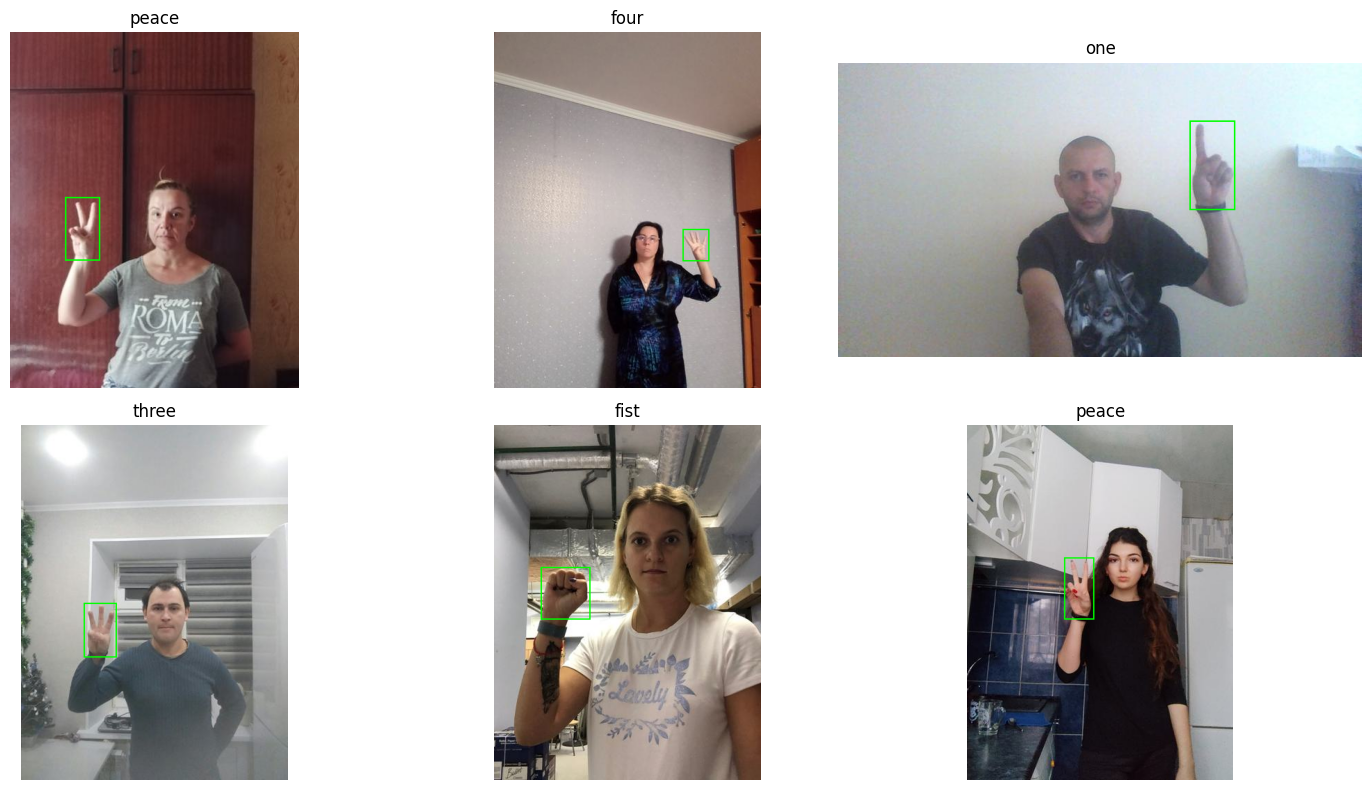

In [8]:
# Use the exact filtered 5-class dataset already prepared in the repo.
# Split by user_id to avoid data leakage (no user should appear in multiple splits)
print("Checking if records have user_id field...")
has_user_id = any('user_id' in r for r in records)

if has_user_id:
    # User-based splitting
    unique_users = list(set([r.get('user_id', 'unknown') for r in records]))
    random.shuffle(unique_users)
    n_users = len(unique_users)
    n_train_users = int(0.7 * n_users)
    n_val_users = int(0.15 * n_users)
    
    train_users = set(unique_users[:n_train_users])
    val_users = set(unique_users[n_train_users:n_train_users + n_val_users])
    test_users = set(unique_users[n_train_users + n_val_users:])
    
    train_records = [r for r in records if r.get('user_id', 'unknown') in train_users]
    val_records = [r for r in records if r.get('user_id', 'unknown') in val_users]
    test_records = [r for r in records if r.get('user_id', 'unknown') in test_users]
    
    print(f"Split by user ID: {len(train_users)} train users, {len(val_users)} val users, {len(test_users)} test users")
else:
    # Fallback to random shuffling if user_id not available (legacy dataset)
    print("WARNING: user_id not available in records. Using random splitting (potential data leakage).")
    random.shuffle(records)
    
    n = len(records)
    n_train = int(0.7 * n)
    n_val = int(0.15 * n)
    
    train_records = records[:n_train]
    val_records = records[n_train:n_train + n_val]
    test_records = records[n_train + n_val:]

print(f"Train: {len(train_records)}, Val: {len(val_records)}, Test: {len(test_records)}")


def draw_box(image, box, color, width=2):
    draw = ImageDraw.Draw(image)
    for offset in range(width):
        draw.rectangle(
            [box[0] - offset, box[1] - offset, box[2] + offset, box[3] + offset],
            outline=color,
        )


def show_samples(samples, n_show=6):
    if len(samples) == 0:
        print("No samples to show")
        return
    idxs = np.random.choice(len(samples), size=min(n_show, len(samples)), replace=False)
    plt.figure(figsize=(15, 8))
    for i, idx in enumerate(idxs, 1):
        s = samples[idx]
        with Image.open(s["image_path"]) as img_pil:
            img = img_pil.convert("RGB")
        x1, y1, x2, y2 = map(int, s["bbox_xyxy"])
        draw_box(img, (x1, y1, x2, y2), color=(0, 255, 0), width=2)
        plt.subplot(2, 3, i)
        plt.imshow(img)
        plt.title(ID_TO_CLASS[s["class_id"]])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_samples(train_records, n_show=6)

In [9]:
IMG_SIZE = 448
BATCH_SIZE = 16
GRID_SIZE = 14 # Changed to 14

def normalize_box_xyxy(box, w, h):
    x1, y1, x2, y2 = box
    return [x1 / w, y1 / h, x2 / w, y2 / h]

class GestureGridDataset(Dataset):
    def __init__(self, records, img_size=448, grid_size=14, augment=False):
        self.records = records
        self.img_size = img_size
        self.grid_size = grid_size
        self.augment = augment

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        r = self.records[idx]
        with Image.open(r["image_path"]) as img_pil:
            img = img_pil.convert("RGB")
            w, h = img.size
            x1, y1, x2, y2 = r["bbox_xyxy"]

            if self.augment:
                if random.random() > 0.5:
                    img = img.transpose(Image.FLIP_LEFT_RIGHT)
                    new_x1 = w - x2
                    new_x2 = w - x1
                    x1, x2 = new_x1, new_x2
                if random.random() > 0.5:
                    from PIL import ImageEnhance
                    enhancer = ImageEnhance.Brightness(img)
                    img = enhancer.enhance(random.uniform(0.8, 1.2))

            x1_n, y1_n, x2_n, y2_n = normalize_box_xyxy([x1, y1, x2, y2], w, h)
            img = img.resize((self.img_size, self.img_size), Image.Resampling.BILINEAR)
            img = np.asarray(img, dtype=np.float32) / 255.0
            img = np.transpose(img, (2, 0, 1))

            target = torch.zeros((self.grid_size, self.grid_size, 6), dtype=torch.float32)
            cx, cy = (x1_n + x2_n) / 2.0, (y1_n + y2_n) / 2.0
            box_w, box_h = max(0.0, x2_n - x1_n), max(0.0, y2_n - y1_n)

            cell_x = min(max(int(cx * self.grid_size), 0), self.grid_size - 1)
            cell_y = min(max(int(cy * self.grid_size), 0), self.grid_size - 1)

            rel_cx = (cx * self.grid_size) - cell_x
            rel_cy = (cy * self.grid_size) - cell_y

            target[cell_y, cell_x, 0] = 1.0
            target[cell_y, cell_x, 1:5] = torch.tensor([rel_cx, rel_cy, box_w, box_h], dtype=torch.float32)
            target[cell_y, cell_x, 5] = float(r["class_id"])

        return {"image": torch.tensor(img, dtype=torch.float32), "target": target}

train_ds = GestureGridDataset(train_records, img_size=IMG_SIZE, grid_size=GRID_SIZE, augment=True)
val_ds = GestureGridDataset(val_records, img_size=IMG_SIZE, grid_size=GRID_SIZE, augment=False)
test_ds = GestureGridDataset(test_records, img_size=IMG_SIZE, grid_size=GRID_SIZE, augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

In [10]:
from torchvision import models

class ResNetDetector(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        # Load pre-trained ResNet18
        resnet = models.resnet18(weights='DEFAULT')
        # Remove the global average pool and FC layer
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])

        # ResNet18 ends with 512 channels for a 224x224 input (output feature map 7x7)
        # For a 448x448 input, the output feature map is 14x14
        self.detection_head = nn.Conv2d(512, 1 + 4 + num_classes, kernel_size=1)

    def forward(self, x):
        feat = self.backbone(x) # Output shape will depend on input X size, e.g., [B, 512, 7, 7] for 224x224 or [B, 512, 14, 14] for 448x448
        out = self.detection_head(feat)
        out = out.permute(0, 2, 3, 1) # [B, grid_y, grid_x, 1+4+num_classes]

        obj_logits = out[..., 0]
        box_preds = torch.sigmoid(out[..., 1:5])
        cls_logits = out[..., 5:]
        return obj_logits, box_preds, cls_logits

# Alias for compatibility with training code
MiniGridDetector = ResNetDetector

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

clean_model = ResNetDetector(num_classes=len(TARGET_CLASSES)).to(device)
print(f"ResNet Backbone model loaded. Total parameters: {count_params(clean_model):,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 166MB/s]


ResNet Backbone model loaded. Total parameters: 11,181,642


In [11]:
def box_iou_xyxy(a, b):
    ax1, ay1, ax2, ay2 = a[..., 0], a[..., 1], a[..., 2], a[..., 3]
    bx1, by1, bx2, by2 = b[..., 0], b[..., 1], b[..., 2], b[..., 3]
    inter_x1 = torch.maximum(ax1, bx1)
    inter_y1 = torch.maximum(ay1, by1)
    inter_x2 = torch.minimum(ax2, bx2)
    inter_y2 = torch.minimum(ay2, by2)
    inter_w = torch.clamp(inter_x2 - inter_x1, min=0)
    inter_h = torch.clamp(inter_y2 - inter_y1, min=0)
    inter = inter_w * inter_h
    area_a = torch.clamp(ax2 - ax1, min=0) * torch.clamp(ay2 - ay1, min=0)
    area_b = torch.clamp(bx2 - bx1, min=0) * torch.clamp(by2 - by1, min=0)
    union = area_a + area_b - inter + 1e-7
    return inter / union

def yolo_loss(obj_logits, box_preds, cls_logits, target_grid, w_obj=1.0, w_box=5.0, w_cls=1.0):
    obj_target = target_grid[..., 0]
    box_target = target_grid[..., 1:5]
    cls_target = target_grid[..., 5].long()
    loss_obj = F.binary_cross_entropy_with_logits(obj_logits, obj_target)
    obj_mask = obj_target == 1.0
    if obj_mask.sum() > 0:
        loss_box = F.smooth_l1_loss(box_preds[obj_mask], box_target[obj_mask])
        loss_cls = F.cross_entropy(cls_logits[obj_mask], cls_target[obj_mask])
    else:
        loss_box = torch.tensor(0.0, device=box_preds.device)
        loss_cls = torch.tensor(0.0, device=cls_logits.device)
    total_loss = (w_obj * loss_obj) + (w_box * loss_box) + (w_cls * loss_cls)
    return total_loss, loss_obj.item(), loss_box.item(), loss_cls.item()

@torch.no_grad()
def decode_batch_predictions(obj_logits, box_preds, cls_logits, target_grid, grid_size: int | None = None):
    if grid_size is None:
        grid_size = obj_logits.shape[-1]

    batch_size = obj_logits.size(0)
    pred_labels, gt_labels, pred_boxes_xyxy, gt_boxes_xyxy = [], [], [], []
    obj_probs = torch.sigmoid(obj_logits)

    for i in range(batch_size):
        pred_flat_idx = torch.argmax(obj_probs[i])
        py, px = int((pred_flat_idx // grid_size).item()), int((pred_flat_idx % grid_size).item())
        gt_obj = target_grid[i, ..., 0]
        if torch.any(gt_obj == 1.0):
            gt_flat_idx = torch.argmax(gt_obj)
            gy, gx = int((gt_flat_idx // grid_size).item()), int((gt_flat_idx % grid_size).item())
        else:
            gy, gx = py, px
        p_rel, g_rel = box_preds[i, py, px], target_grid[i, gy, gx, 1:5]
        p_cx, p_cy = (px + p_rel[0]) / grid_size, (py + p_rel[1]) / grid_size
        g_cx, g_cy = (gx + g_rel[0]) / grid_size, (gy + g_rel[1]) / grid_size
        p_box = torch.stack([p_cx - (p_rel[2] / 2), p_cy - (p_rel[3] / 2), p_cx + (p_rel[2] / 2), p_cy + (p_rel[3] / 2)]).clamp(0, 1)
        g_box = torch.stack([g_cx - (g_rel[2] / 2), g_cy - (g_rel[3] / 2), g_cx + (g_rel[2] / 2), g_cy + (g_rel[3] / 2)]).clamp(0, 1)
        pred_boxes_xyxy.append(p_box)
        gt_boxes_xyxy.append(g_box)
        pred_labels.append(int(torch.argmax(cls_logits[i, py, px]).item()))
        gt_labels.append(int(target_grid[i, gy, gx, 5].item()))
    return pred_labels, gt_labels, torch.stack(pred_boxes_xyxy), torch.stack(gt_boxes_xyxy)

@torch.no_grad()
def evaluate_model(model, loader):
    model.eval()
    gt_labels, pred_labels, ious, all_lat_ms = [], [], [], []
    for batch in tqdm(loader, leave=False):
        x, target_grid = batch["image"].to(device), batch["target"].to(device)
        if device.type == "cuda": torch.cuda.synchronize()
        t0 = time.perf_counter()
        obj_logits, box_preds, cls_logits = model(x)
        if device.type == "cuda": torch.cuda.synchronize()
        t1 = time.perf_counter()
        all_lat_ms.extend([(t1 - t0) * 1000.0 / x.size(0)] * x.size(0))
        p_l, g_l, p_b, g_b = decode_batch_predictions(obj_logits, box_preds, cls_logits, target_grid, GRID_SIZE)
        gt_labels.extend(g_l); pred_labels.extend(p_l); ious.extend(box_iou_xyxy(p_b, g_b).cpu().numpy().tolist())
    acc = accuracy_score(gt_labels, pred_labels)
    prec, rec, f1, _ = precision_recall_fscore_support(gt_labels, pred_labels, average="macro", zero_division=0)
    return {"accuracy": acc, "precision_macro": prec, "recall_macro": rec, "f1_macro": f1, "mean_iou": float(np.mean(ious)), "latency_mean_ms": float(np.mean(all_lat_ms))}

def fit_model(model, train_loader, val_loader, epochs=2, lr=1e-3, save_path=None):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = []
    best_acc = 0.0
    for ep in range(1, epochs + 1):
        model.train()
        train_loss = 0.0
        for batch in tqdm(train_loader, leave=False):
            x, target_grid = batch["image"].to(device), batch["target"].to(device)
            optimizer.zero_grad()
            obj_logits, box_preds, cls_logits = model(x)
            loss, _, _, _ = yolo_loss(obj_logits, box_preds, cls_logits, target_grid)
            loss.backward(); optimizer.step()
            train_loss += loss.item() * x.size(0)
        train_loss /= len(train_loader.dataset)
        val_metrics = evaluate_model(model, val_loader)
        history.append({"epoch": ep, "train_loss": train_loss, **val_metrics})

        # --- Best Model Logic ---
        if val_metrics['accuracy'] > best_acc:
            best_acc = val_metrics['accuracy']
            if save_path:
                torch.save({"model_state_dict": model.state_dict(), "accuracy": best_acc}, save_path)
                print(f"Epoch {ep:02d} | New Best Val Acc: {best_acc:.4f} (Saved)")
        else:
            print(f"Epoch {ep:02d} | loss={train_loss:.4f} | val_acc={val_metrics['accuracy']:.4f}")
    return pd.DataFrame(history)

def fit_model_with_scheduler(model, train_loader, val_loader, epochs=20, lr=1e-4, save_path=None, **model_metadata):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

    history = []
    best_acc = 0.0
    best_epoch_model_state = None # To store the state_dict of the best model

    for ep in range(1, epochs + 1):
        model.train()
        train_loss = 0.0
        t0 = time.perf_counter()

        for batch in tqdm(train_loader, leave=False):
            x, target_grid = batch["image"].to(device), batch["target"].to(device)
            optimizer.zero_grad()
            obj_logits, box_preds, cls_logits = model(x)
            loss, l_obj, l_box, l_cls = yolo_loss(obj_logits, box_preds, cls_logits, target_grid)
            loss.backward(); optimizer.step()
            train_loss += loss.item() * x.size(0)

        t1 = time.perf_counter()
        epoch_time = t1 - t0
        avg_train_loss = train_loss / len(train_loader.dataset)

        val_metrics = evaluate_model(model, val_loader)
        scheduler.step(val_metrics['accuracy'])

        status = {"epoch": ep, "train_loss": avg_train_loss, "latency_ms": (epoch_time/len(train_loader))*1000, **val_metrics}
        history.append(status)

        print(f"Epoch {ep:02d} | Loss: {avg_train_loss:.4f} | Val Acc: {val_metrics['accuracy']:.4f} | Latency: {val_metrics['latency_mean_ms']:.2f}ms")

        if val_metrics['accuracy'] > best_acc:
            best_acc = val_metrics['accuracy']
            best_epoch_model_state = model.state_dict() # Save the state_dict
            print(f"--- New Best Val Acc: {best_acc:.4f} (Model Saved) ---")
            if save_path:
                # Prepare checkpoint to save
                checkpoint_to_save = {
                    "model_state_dict": best_epoch_model_state,
                    "best_accuracy": best_acc, # Save the best accuracy achieved
                    **model_metadata # Include other metadata like class_to_id, img_size etc.
                }
                torch.save(checkpoint_to_save, save_path)
                print(f"Model checkpoint saved to {save_path} for best accuracy: {best_acc:.4f}")

    return pd.DataFrame(history)

In [12]:
@torch.no_grad()
def decode_single_prediction(obj_logits, box_preds, cls_logits, w, h, grid_size: int | None = None):
    """
    Decodes the single most confident prediction from the model's grid output.
    Returns: [x1, y1, x2, y2], class_id, confidence_score
    """
    if grid_size is None:
        grid_size = obj_logits.shape[-1]

    obj_probs = torch.sigmoid(obj_logits[0])
    flat_idx = torch.argmax(obj_probs)
    py, px = int(flat_idx // grid_size), int(flat_idx % grid_size)
    score = obj_probs[py, px].item()
    rel = box_preds[0, py, px]
    cx = (px + rel[0]) / grid_size
    cy = (py + rel[1]) / grid_size
    bw, bh = rel[2], rel[3]
    x1, y1 = (cx - bw / 2) * w, (cy - bh / 2) * h
    x2, y2 = (cx + bw / 2) * w, (cy + bh / 2) * h
    class_id = torch.argmax(cls_logits[0, py, px]).item()
    return [float(x1), float(y1), float(x2), float(y2)], int(class_id), float(score)

In [13]:
from torchvision.ops import nms

@torch.no_grad()
def decode_and_nms(obj_logits, box_preds, cls_logits, grid_size: int | None = None, score_threshold=0.5, iou_threshold=0.4):
    """
    Decodes all grid cells and applies Non-Maximum Suppression.
    This is essential for live detection where a hand might overlap multiple grid cells.
    """
    if grid_size is None:
        grid_size = obj_logits.shape[-1]

    batch_size = obj_logits.size(0)
    final_preds = []
    obj_probs = torch.sigmoid(obj_logits)

    for b in range(batch_size):
        probs = obj_probs[b].view(-1)
        mask = probs > score_threshold

        if not mask.any():
            final_preds.append(None)
            continue

        filtered_probs = probs[mask]
        indices = torch.nonzero(mask).squeeze(1)
        py = indices // grid_size
        px = indices % grid_size
        rel_boxes = box_preds[b, py, px]
        p_cx = (px.float() + rel_boxes[:, 0]) / grid_size
        p_cy = (py.float() + rel_boxes[:, 1]) / grid_size
        p_w, p_h = rel_boxes[:, 2], rel_boxes[:, 3]
        boxes = torch.stack([
            p_cx - p_w / 2, p_cy - p_h / 2,
            p_cx + p_w / 2, p_cy + p_h / 2
        ], dim=1).clamp(0, 1)
        keep_idx = nms(boxes, filtered_probs, iou_threshold)
        class_ids = torch.argmax(cls_logits[b, py, px], dim=1)
        final_preds.append({
            "boxes": boxes[keep_idx],
            "scores": filtered_probs[keep_idx],
            "labels": class_ids[keep_idx]
        })

    return final_preds

print("NMS post-processing logic integrated for better live detection stability.")

NMS post-processing logic integrated for better live detection stability.


In [14]:
@torch.no_grad()
def decode_batch_predictions(obj_logits, box_preds, cls_logits, target_grid, grid_size: int | None = None):
    if grid_size is None:
        grid_size = obj_logits.shape[-1]

    batch_size = obj_logits.size(0)
    pred_labels, gt_labels, pred_boxes_xyxy, gt_boxes_xyxy = [], [], [], []
    obj_probs = torch.sigmoid(obj_logits)

    for i in range(batch_size):
        pred_flat_idx = torch.argmax(obj_probs[i])
        py, px = int((pred_flat_idx // grid_size).item()), int((pred_flat_idx % grid_size).item())
        gt_obj = target_grid[i, ..., 0]
        if torch.any(gt_obj == 1.0):
            gt_flat_idx = torch.argmax(gt_obj)
            gy, gx = int((gt_flat_idx // grid_size).item()), int((gt_flat_idx % grid_size).item())
        else:
            gy, gx = py, px
        p_rel, g_rel = box_preds[i, py, px], target_grid[i, gy, gx, 1:5]
        p_cx, p_cy = (px + p_rel[0]) / grid_size, (py + p_rel[1]) / grid_size
        g_cx, g_cy = (gx + g_rel[0]) / grid_size, (gy + g_rel[1]) / grid_size
        p_box = torch.stack([p_cx - (p_rel[2] / 2), p_cy - (p_rel[3] / 2), p_cx + (p_rel[2] / 2), p_cy + (p_rel[3] / 2)]).clamp(0, 1)
        g_box = torch.stack([g_cx - (g_rel[2] / 2), g_cy - (g_rel[3] / 2), g_cx + (g_rel[2] / 2), g_cy + (g_rel[3] / 2)]).clamp(0, 1)
        pred_boxes_xyxy.append(p_box)
        gt_boxes_xyxy.append(g_box)
        pred_labels.append(int(torch.argmax(cls_logits[i, py, px]).item()))
        gt_labels.append(int(target_grid[i, gy, gx, 5].item()))
    return pred_labels, gt_labels, torch.stack(pred_boxes_xyxy), torch.stack(gt_boxes_xyxy)


@torch.no_grad()
def decode_single_prediction(obj_logits, box_preds, cls_logits, w, h, grid_size: int | None = None):
    """
    Decodes the single most confident prediction from the model's grid output.
    Returns: [x1, y1, x2, y2], class_id, confidence_score
    """
    if grid_size is None:
        grid_size = obj_logits.shape[-1]

    obj_probs = torch.sigmoid(obj_logits[0])
    flat_idx = torch.argmax(obj_probs)
    py, px = int(flat_idx // grid_size), int(flat_idx % grid_size)
    score = obj_probs[py, px].item()
    rel = box_preds[0, py, px]
    cx = (px + rel[0]) / grid_size
    cy = (py + rel[1]) / grid_size
    bw, bh = rel[2], rel[3]
    x1, y1 = (cx - bw / 2) * w, (cy - bh / 2) * h
    x2, y2 = (cx + bw / 2) * w, (cy + bh / 2) * h
    class_id = torch.argmax(cls_logits[0, py, px]).item()
    return [float(x1), float(y1), float(x2), float(y2)], int(class_id), float(score)


@torch.no_grad()
def decode_and_nms(obj_logits, box_preds, cls_logits, grid_size: int | None = None, score_threshold=0.5, iou_threshold=0.4):
    """
    Decodes all grid cells and applies Non-Maximum Suppression.
    This is essential for live detection where a hand might overlap multiple grid cells.
    """
    if grid_size is None:
        grid_size = obj_logits.shape[-1]

    batch_size = obj_logits.size(0)
    final_preds = []
    obj_probs = torch.sigmoid(obj_logits)

    for b in range(batch_size):
        probs = obj_probs[b].view(-1)
        mask = probs > score_threshold

        if not mask.any():
            final_preds.append(None)
            continue

        filtered_probs = probs[mask]
        indices = torch.nonzero(mask).squeeze(1)
        py = indices // grid_size
        px = indices % grid_size
        rel_boxes = box_preds[b, py, px]
        p_cx = (px.float() + rel_boxes[:, 0]) / grid_size
        p_cy = (py.float() + rel_boxes[:, 1]) / grid_size
        p_w, p_h = rel_boxes[:, 2], rel_boxes[:, 3]
        boxes = torch.stack([
            p_cx - p_w / 2, p_cy - p_h / 2,
            p_cx + p_w / 2, p_cy + p_h / 2
        ], dim=1).clamp(0, 1)
        keep_idx = nms(boxes, filtered_probs, iou_threshold)
        class_ids = torch.argmax(cls_logits[b, py, px], dim=1)
        final_preds.append({
            "boxes": boxes[keep_idx],
            "scores": filtered_probs[keep_idx],
            "labels": class_ids[keep_idx]
        })

    return final_preds

In [15]:
import torch
import numpy as np
import matplotlib.patches as patches

@torch.no_grad()
def visualize_resnet_nms(model, dataset, n_show=4, score_thr=0.5, iou_thr=0.4):
    model.eval()
    indices = np.random.choice(len(dataset), size=n_show, replace=False)

    fig, axs = plt.subplots(1, n_show, figsize=(20, 5))
    if n_show == 1: axs = [axs]

    for i, idx in enumerate(indices):
        batch = dataset[idx]
        img_tensor = batch["image"].unsqueeze(0).to(device)

        # Inference
        obj_logits, box_preds, cls_logits = model(img_tensor)

        # Apply your new NMS logic
        preds = decode_and_nms(obj_logits, box_preds, cls_logits,
                               grid_size=GRID_SIZE,
                               score_threshold=score_thr,
                               iou_threshold=iou_thr)[0]

        # Convert tensor to image for display
        img = img_tensor[0].cpu().permute(1, 2, 0).numpy()
        axs[i].imshow(img)
        axs[i].axis("off")

        if preds is not None:
            for box, score, label in zip(preds["boxes"], preds["scores"], preds["labels"]):
                x1, y1, x2, y2 = box.cpu().numpy() * IMG_SIZE
                rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor='r', facecolor='none')
                axs[i].add_patch(rect)
                axs[i].set_title(f"{ID_TO_CLASS[int(label)]} ({score:.2f})")
        else:
            axs[i].set_title("No detection")

print("ResNet visualization helper with NMS is ready.")

ResNet visualization helper with NMS is ready.


In [16]:
# Re-training ResNet-18 with higher resolution and lower learning rate
MODEL_PATH = MODEL_DIR / "resnet18_hagrid_detector.pt"
EPOCHS = 20
LR = 1e-4

clean_model = ResNetDetector(num_classes=len(TARGET_CLASSES)).to(device)
print(f"Training ResNet-18 with resolution {IMG_SIZE} and LR {LR}...")

# Pass save_path and other metadata to the training function
history_df = fit_model_with_scheduler(
    clean_model,
    train_loader,
    val_loader,
    epochs=EPOCHS,
    lr=LR,
    save_path=MODEL_PATH, # Pass the path to save the best model
    class_to_id=CLASS_TO_ID,
    img_size=IMG_SIZE,
    grid_size=GRID_SIZE,
    model_name="ResNet18",
)

print("Training complete. Best model (if any) saved during training.")

Training ResNet-18 with resolution 448 and LR 0.0001...


  0%|          | 0/386 [00:00<?, ?it/s]

  0%|          | 0/82 [00:00<?, ?it/s]

Epoch 01 | Loss: 0.6597 | Val Acc: 0.8416 | Latency: 3.08ms
--- New Best Val Acc: 0.8416 (Model Saved) ---
Model checkpoint saved to /kaggle/working/models/resnet18_hagrid_detector.pt for best accuracy: 0.8416


  0%|          | 0/386 [00:00<?, ?it/s]

...

  0%|          | 0/82 [00:00<?, ?it/s]

Epoch 19 | Loss: 0.0181 | Val Acc: 0.9610 | Latency: 3.06ms
--- New Best Val Acc: 0.9610 (Model Saved) ---
Model checkpoint saved to /kaggle/working/models/resnet18_hagrid_detector.pt for best accuracy: 0.9610


  0%|          | 0/386 [00:00<?, ?it/s]

  0%|          | 0/82 [00:00<?, ?it/s]

Epoch 20 | Loss: 0.0135 | Val Acc: 0.9503 | Latency: 3.05ms
Training complete. Best model (if any) saved during training.


In [17]:
from google.colab import files

# Path to the trained model file
model_to_download = MODEL_DIR / "resnet18_hagrid_detector.pt"

# Check if the file exists before attempting to download
if model_to_download.exists():
    files.download(str(model_to_download))
    print(f"'{model_to_download.name}' downloaded successfully to your local machine.")
else:
    print(f"Model file not found at {model_to_download}. Please ensure the model training and saving steps were completed successfully.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

'resnet18_hagrid_detector.pt' downloaded successfully to your local machine.


  0%|          | 0/86 [00:00<?, ?it/s]


--- Classification Report ---
              precision    recall  f1-score   support

         one       0.94      0.97      0.95       280
       peace       0.94      0.94      0.94       289
       three       0.93      0.92      0.93       260
        four       0.96      0.94      0.95       269
        fist       0.96      0.96      0.96       268

    accuracy                           0.95      1366
   macro avg       0.95      0.95      0.95      1366
weighted avg       0.95      0.95      0.95      1366



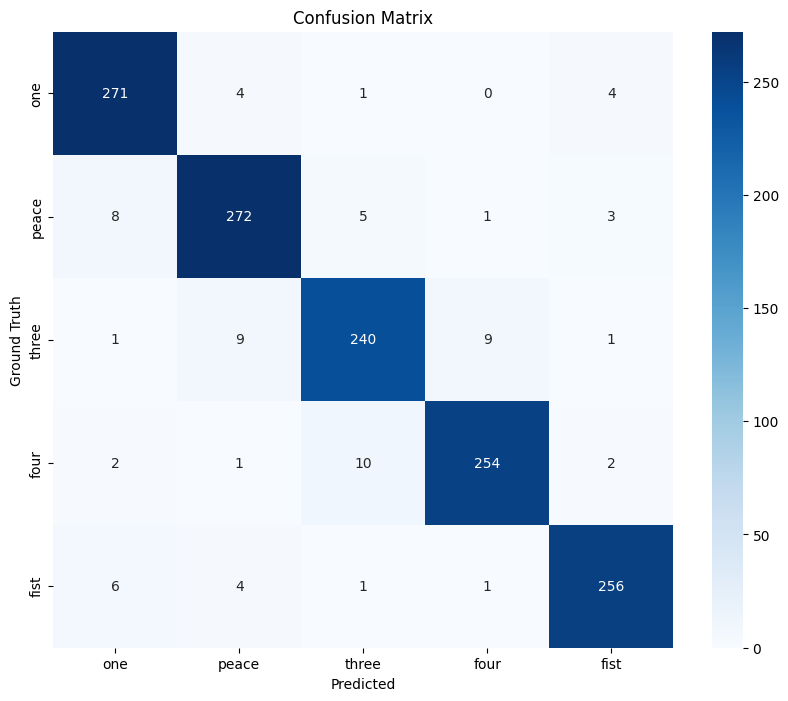

In [18]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

@torch.no_grad()
def final_report(model, loader):
    model.eval()
    gt_labels, pred_labels = [], []
    for batch in tqdm(loader):
        x, target_grid = batch["image"].to(device), batch["target"].to(device)
        obj_logits, box_preds, cls_logits = model(x)
        p_l, g_l, _, _ = decode_batch_predictions(obj_logits, box_preds, cls_logits, target_grid, GRID_SIZE)
        gt_labels.extend(g_l)
        pred_labels.extend(p_l)

    # Class-wise metrics
    print("\n--- Classification Report ---")
    print(classification_report(gt_labels, pred_labels, target_names=TARGET_CLASSES))

    # Confusion Matrix
    cm = confusion_matrix(gt_labels, pred_labels)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=TARGET_CLASSES, yticklabels=TARGET_CLASSES)
    plt.xlabel('Predicted')
    plt.ylabel('Ground Truth')
    plt.title('Confusion Matrix')
    plt.show()

if 'clean_model' in globals():
    final_report(clean_model, test_loader)
else:
    print("Model not trained yet.")

Saved splits to: /kaggle/working/models/resnet18_splits.json
Saved environment info to: /kaggle/working/models/resnet18_env_info.txt


  0%|          | 0/86 [00:00<?, ?it/s]

Saved classification report to: /kaggle/working/models/resnet18_classification_report.json


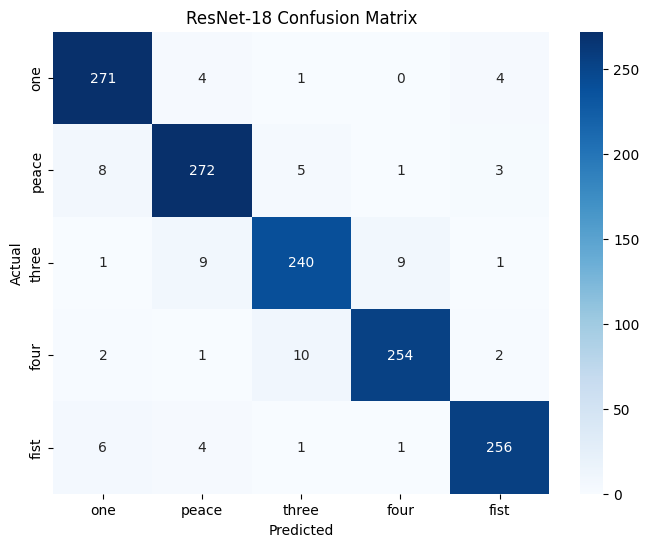

Saved confusion matrix image to: /kaggle/working/models/resnet18_confusion_matrix.png
Saved training history to: /kaggle/working/models/resnet18_training_history.csv
Saved report summary to: /kaggle/working/models/resnet18_report_summary.json


In [19]:
# Save split indices, environment details, and evaluation artifacts
import json, platform, subprocess, sys
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

REPORT_DIR = MODEL_DIR
REPORT_DIR.mkdir(parents=True, exist_ok=True)

# 1) Persist train/val/test splits
splits = {
    'train': [r['image_path'] for r in train_records],
    'val': [r['image_path'] for r in val_records],
    'test': [r['image_path'] for r in test_records],
}
with open(REPORT_DIR / 'resnet18_splits.json', 'w', encoding='utf-8') as f:
    json.dump(splits, f, indent=2)
print(f"Saved splits to: {REPORT_DIR / 'resnet18_splits.json'}")

# 2) Record environment details and pinned package snapshot
env_info = {
    'python': sys.version,
    'platform': platform.platform(),
    'torch': torch.__version__,
}
try:
    pip_freeze = subprocess.check_output([sys.executable, '-m', 'pip', 'freeze'], stderr=subprocess.DEVNULL).decode('utf-8')
    env_info['pip_freeze'] = pip_freeze
except Exception as e:
    env_info['pip_freeze'] = f'pip freeze failed: {e}'

with open(REPORT_DIR / 'resnet18_env_info.txt', 'w', encoding='utf-8') as f:
    for k, v in env_info.items():
        if k == 'pip_freeze':
            f.write('\n== pip freeze ==\n')
            f.write(v)
        else:
            f.write(f"{k}: {v}\n")
print(f"Saved environment info to: {REPORT_DIR / 'resnet18_env_info.txt'}")

# 3) Save classification report + confusion matrix from test predictions
if 'clean_model' in globals() and 'test_loader' in globals():
    clean_model.eval()
    all_preds, all_gts = [], []
    for batch in tqdm(test_loader, leave=False):
        x, target_grid = batch['image'].to(device), batch['target'].to(device)
        obj_logits, box_preds, cls_logits = clean_model(x)
        p_l, g_l, _, _ = decode_batch_predictions(obj_logits, box_preds, cls_logits, target_grid, GRID_SIZE)
        all_preds.extend(p_l)
        all_gts.extend(g_l)

    clf_report = classification_report(all_gts, all_preds, target_names=TARGET_CLASSES, output_dict=True, zero_division=0)
    with open(REPORT_DIR / 'resnet18_classification_report.json', 'w', encoding='utf-8') as f:
        json.dump(clf_report, f, indent=2)
    print(f"Saved classification report to: {REPORT_DIR / 'resnet18_classification_report.json'}")

    cm = confusion_matrix(all_gts, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=TARGET_CLASSES, yticklabels=TARGET_CLASSES)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('ResNet-18 Confusion Matrix')
    cm_path = REPORT_DIR / 'resnet18_confusion_matrix.png'
    plt.savefig(cm_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved confusion matrix image to: {cm_path}")

    if 'history_df' in globals():
        history_csv = REPORT_DIR / 'resnet18_training_history.csv'
        history_df.to_csv(history_csv, index=False)
        print(f"Saved training history to: {history_csv}")

    summary = {
        'best_model_path': str(MODEL_PATH) if 'MODEL_PATH' in globals() else str(REPORT_DIR / 'resnet18_hagrid_detector.pt'),
        'model_exists': (MODEL_PATH.exists() if 'MODEL_PATH' in globals() else (REPORT_DIR / 'resnet18_hagrid_detector.pt').exists()),
        'splits_file': str(REPORT_DIR / 'resnet18_splits.json'),
        'env_info_file': str(REPORT_DIR / 'resnet18_env_info.txt'),
        'classification_report': str(REPORT_DIR / 'resnet18_classification_report.json'),
        'confusion_matrix': str(REPORT_DIR / 'resnet18_confusion_matrix.png'),
    }
    with open(REPORT_DIR / 'resnet18_report_summary.json', 'w', encoding='utf-8') as f:
        json.dump(summary, f, indent=2)
    print(f"Saved report summary to: {REPORT_DIR / 'resnet18_report_summary.json'}")
else:
    print('Model or test_loader not available in the notebook state; run training and evaluation cells first.')

In [20]:
@torch.no_grad()
def visualize_predictions(model, dataset, n_show=8, score_thr=0.1, iou_thr=0.4):
    if len(dataset) == 0:
        print("Dataset empty")
        return

    model.eval()
    idxs = np.random.choice(len(dataset), size=min(n_show, len(dataset)), replace=False)
    plt.figure(figsize=(20, 12))

    for i, idx in enumerate(idxs, 1):
        sample = dataset.records[idx]
        with Image.open(sample["image_path"]) as img_pil:
            img = img_pil.convert("RGB")
            w, h = img.size

            # Prep input
            resized = img.resize((IMG_SIZE, IMG_SIZE), Image.Resampling.BILINEAR)
            x = np.asarray(resized, dtype=np.float32) / 255.0
            xt = torch.tensor(np.transpose(x, (2, 0, 1)), dtype=torch.float32).unsqueeze(0).to(device)

            # Inference
            obj_logits, box_preds, cls_logits = model(xt)
            preds_list = decode_and_nms(obj_logits, box_preds, cls_logits, grid_size=GRID_SIZE, score_threshold=score_thr, iou_threshold=iou_thr)
            preds = preds_list[0]

            # Draw Ground Truth (Green)
            gx1, gy1, gx2, gy2 = map(int, sample["bbox_xyxy"])
            draw_box(img, (gx1, gy1, gx2, gy2), color=(0, 255, 0), width=3)

            pred_text = "No Detection"
            if preds is not None and len(preds["boxes"]) > 0:
                # NMS returns normalized [0, 1] coords
                box = preds["boxes"][0].cpu().numpy()
                score = preds["scores"][0].item()
                label = preds["labels"][0].item()

                # RESCALE TO PIXELS
                px1, py1 = int(box[0] * w), int(box[1] * h)
                px2, py2 = int(box[2] * w), int(box[3] * h)

                print(f"Img {i} | Box Norm: {box} | Box Pixel: {[px1, py1, px2, py2]}")

                draw_box(img, (px1, py1, px2, py2), color=(255, 0, 0), width=5)
                pred_text = f"Pred: {ID_TO_CLASS[label]} ({score:.2f})"

            plt.subplot((n_show + 3) // 4, 4, i)
            plt.imshow(img)
            plt.title(f"GT: {ID_TO_CLASS[sample['class_id']]}\n{pred_text}")
            plt.axis("off")

    plt.tight_layout()
    plt.show()

Img 1 | Box Norm: [0.57032055 0.3768863  0.68228084 0.5168655 ] | Box Pixel: [219, 192, 261, 264]
Img 2 | Box Norm: [0.3003947  0.20296834 0.47321653 0.41268915] | Box Pixel: [115, 104, 181, 211]
Img 4 | Box Norm: [0.4348286  0.601453   0.48737785 0.6477564 ] | Box Pixel: [166, 308, 187, 332]
Img 6 | Box Norm: [0.29326898 0.5655312  0.3708706  0.70677394] | Box Pixel: [112, 289, 142, 361]
Img 7 | Box Norm: [0.3228091  0.32331398 0.4154061  0.44602963] | Box Pixel: [123, 165, 159, 228]
Img 8 | Box Norm: [0.17664152 0.30827034 0.2922692  0.4365394 ] | Box Pixel: [67, 157, 112, 223]


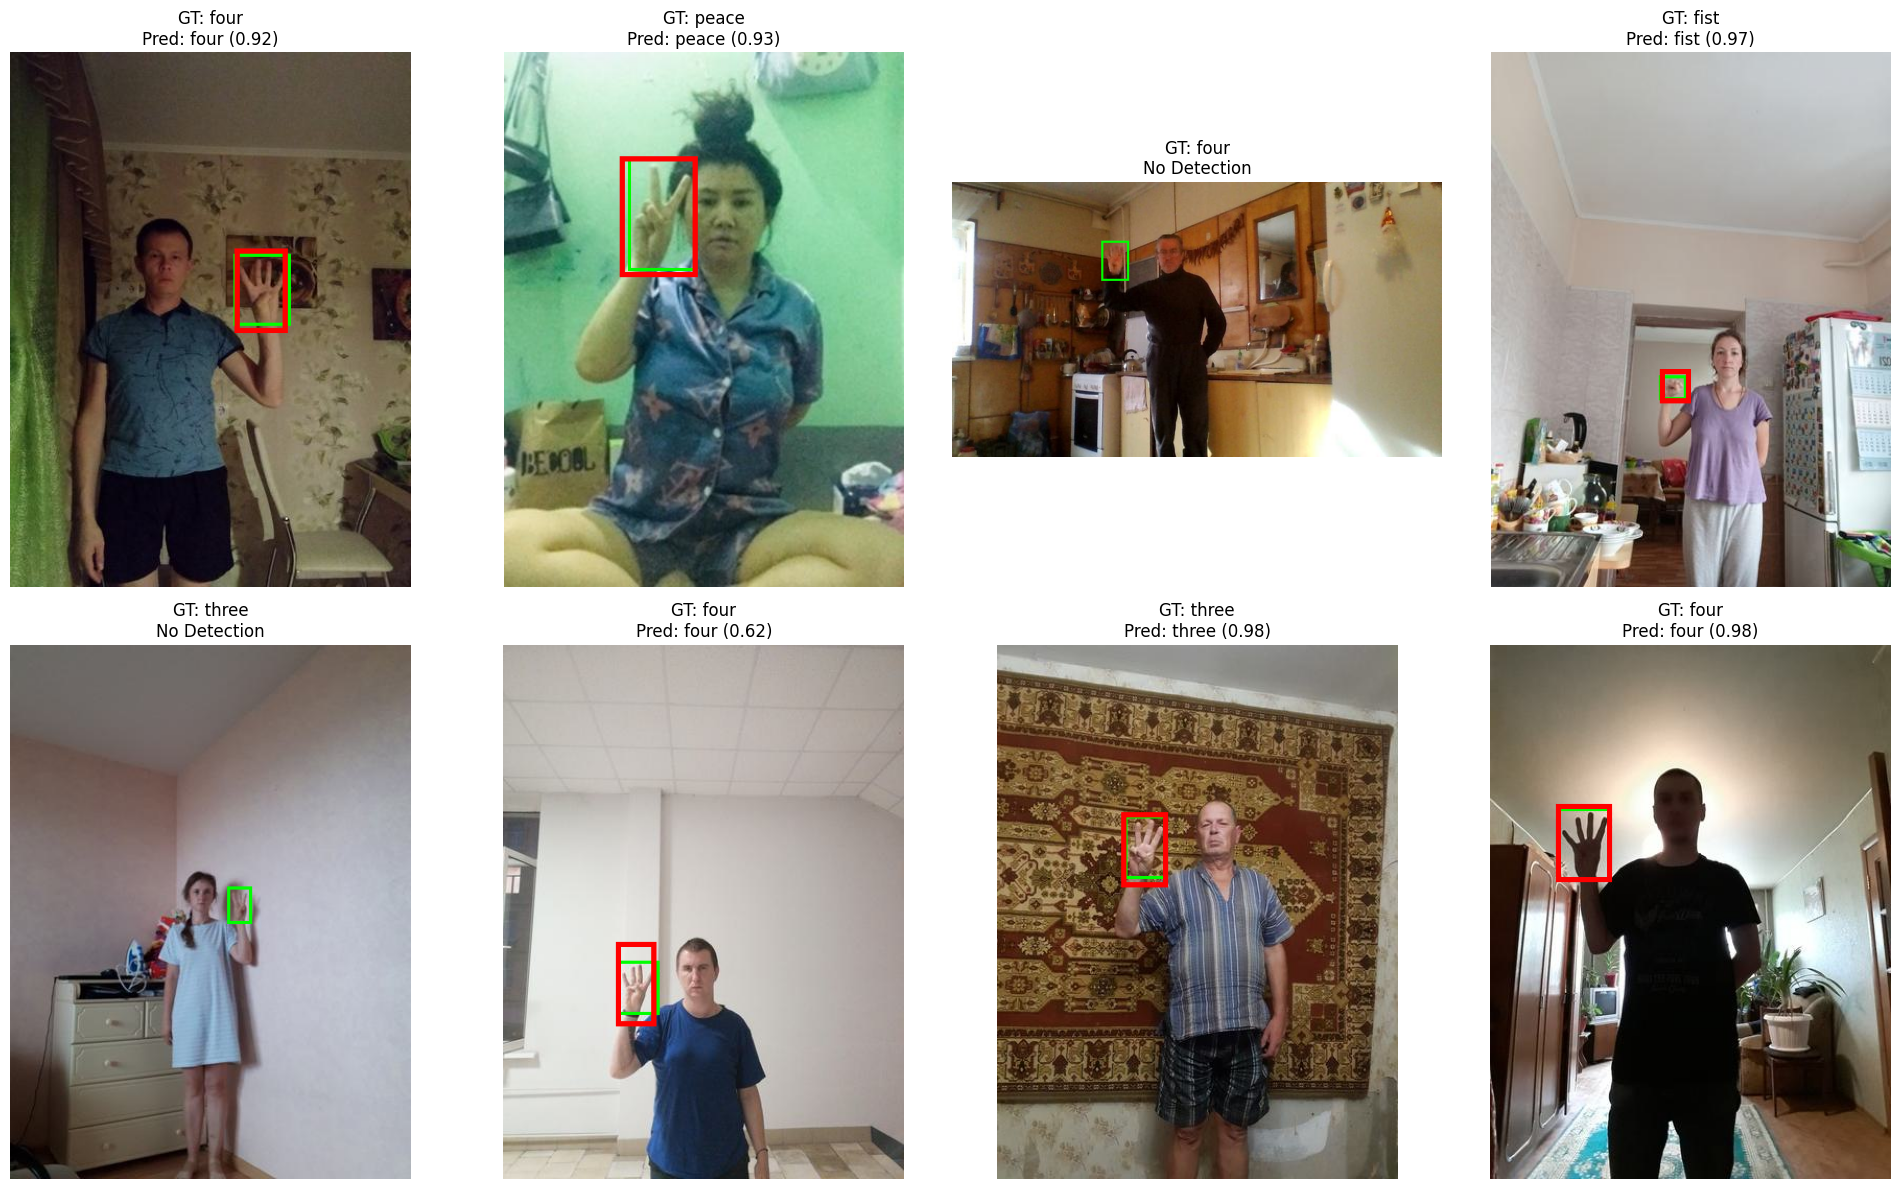

In [21]:
# Re-running visualization with red prediction boxes and score threshold 0.3
visualize_predictions(clean_model, test_ds, n_show=8, score_thr=0.3)

In [22]:
# Evaluate the model on the test set
print("Evaluating ResNet model on test data...")
test_metrics = evaluate_model(clean_model, test_loader)

# Display metrics nicely
metrics_df = pd.DataFrame([test_metrics])
display(metrics_df)

Evaluating ResNet model on test data...


  0%|          | 0/86 [00:00<?, ?it/s]

,accuracy,precision_macro,recall_macro,f1_macro,mean_iou,latency_mean_ms
0,0.946559,0.94673,0.946314,0.946464,0.735528,3.100574


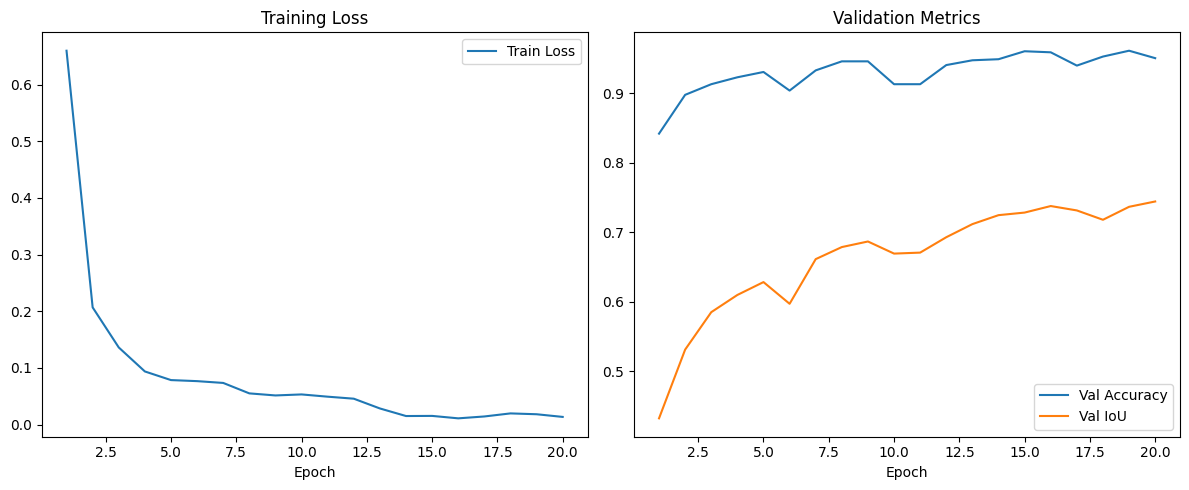

In [23]:
def plot_history(df):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(df['epoch'], df['train_loss'], label='Train Loss')
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(df['epoch'], df['accuracy'], label='Val Accuracy')
    plt.plot(df['epoch'], df['mean_iou'], label='Val IoU')
    plt.title('Validation Metrics')
    plt.xlabel('Epoch')
    plt.legend()

    plt.tight_layout()
    plt.show()

if 'history_df' in globals():
    plot_history(history_df)
else:
    print("History not found. Ensure the training cell was executed.")

### Using the Trained Model for Inference

Here's how you can load your trained model and use it to make predictions on new images. You would typically do this in a separate script or when deploying your model.

Model 'ResNet18' loaded from /kaggle/working/models/resnet18_hagrid_detector.pt
Trained with image size: 448, grid size: 14
No objects detected.


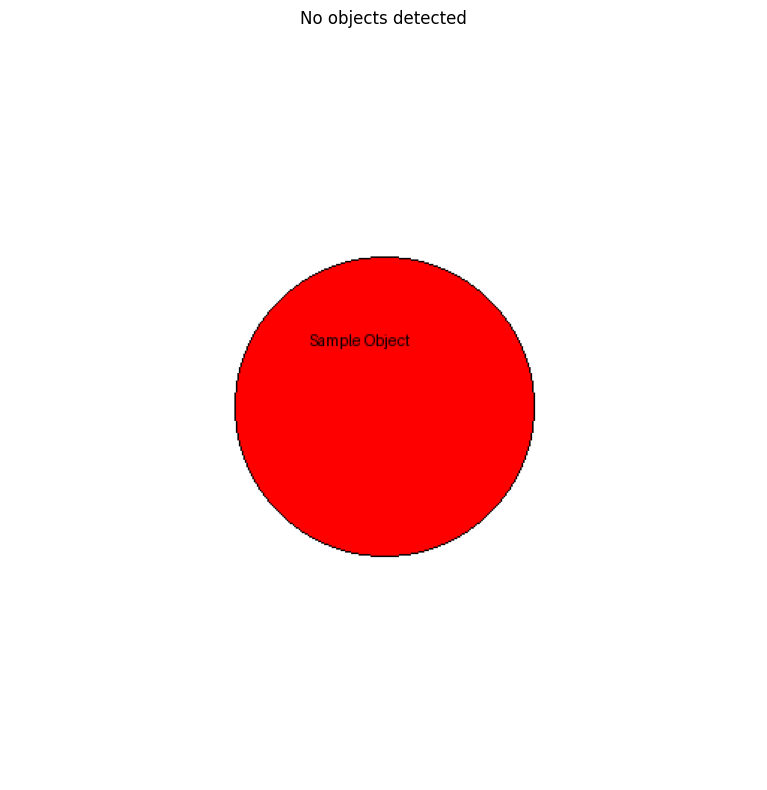

In [24]:
import torch
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Assuming ResNetDetector, decode_and_nms, ID_TO_CLASS, IMG_SIZE, GRID_SIZE are defined
# (You would need to import these definitions in a fresh script)

# Load model checkpoint
model_path = MODEL_DIR / "resnet18_hagrid_detector.pt"
checkpoint = torch.load(model_path, map_location=device)

# Initialize the model architecture
# Make sure num_classes matches the training configuration
loaded_model = ResNetDetector(num_classes=len(checkpoint['class_to_id'])).to(device)
loaded_model.load_state_dict(checkpoint['model_state_dict'])
loaded_model.eval()

print(f"Model '{checkpoint['model_name']}' loaded from {model_path}")
print(f"Trained with image size: {checkpoint['img_size']}, grid size: {checkpoint['grid_size']}")

# Use the parameters from the loaded checkpoint
INFERENCE_IMG_SIZE = checkpoint['img_size']
INFERENCE_GRID_SIZE = checkpoint['grid_size']
INFERENCE_ID_TO_CLASS = {v: k for k, v in checkpoint['class_to_id'].items()}

# Create a dummy blank image for demonstration
# In a real scenario, you'd load an actual image:
# img_path = "/path/to/your/image.jpg"
# original_img_pil = Image.open(img_path).convert("RGB")

original_img_pil = Image.new('RGB', (500, 500), color = 'white') # Dummy image
draw = ImageDraw.Draw(original_img_pil)
draw.ellipse([150, 150, 350, 350], fill=(255, 0, 0), outline=(0, 0, 0))
draw.text((200, 200), "Sample Object", fill=(0,0,0))

w_orig, h_orig = original_img_pil.size

# Preprocess the image
resized_img_pil = original_img_pil.resize((INFERENCE_IMG_SIZE, INFERENCE_IMG_SIZE), Image.Resampling.BILINEAR)
x = np.asarray(resized_img_pil, dtype=np.float32) / 255.0
xt = torch.tensor(np.transpose(x, (2, 0, 1)), dtype=torch.float32).unsqueeze(0).to(device)

# Perform inference
with torch.no_grad():
    obj_logits, box_preds, cls_logits = loaded_model(xt)

# Decode predictions using NMS
preds_list = decode_and_nms(obj_logits, box_preds, cls_logits,
                             grid_size=INFERENCE_GRID_SIZE,
                             score_threshold=0.3, # Adjust as needed
                             iou_threshold=0.4)
preds = preds_list[0]

# Visualize results
fig, ax = plt.subplots(1, figsize=(8, 8))
ax.imshow(original_img_pil)
ax.axis("off")

if preds is not None and len(preds["boxes"]) > 0:
    print(f"Detected {len(preds['boxes'])} objects:")
    for box, score, label in zip(preds["boxes"], preds["scores"], preds["labels"]):
        # Rescale normalized box coordinates back to original image dimensions
        x1, y1, x2, y2 = box.cpu().numpy()
        x1_abs, y1_abs, x2_abs, y2_abs = x1 * w_orig, y1 * h_orig, x2 * w_orig, y2 * h_orig

        rect = patches.Rectangle((x1_abs, y1_abs), x2_abs - x1_abs, y2_abs - y1_abs,
                                 linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)
        ax.text(x1_abs, y1_abs - 5, f"{INFERENCE_ID_TO_CLASS[label.item()]} ({score:.2f})",
                bbox=dict(facecolor='yellow', alpha=0.5), fontsize=10, color='black')
        print(f"  Class: {INFERENCE_ID_TO_CLASS[label.item()]}, Score: {score:.2f}, Box: {[x1_abs, y1_abs, x2_abs, y2_abs]}")
else:
    ax.set_title("No objects detected")
    print("No objects detected.")

plt.tight_layout()
plt.show()